In [323]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler


In [324]:
df = pd.read_csv('/users/imbahndu/Desktop/Columbia DBM/Typing dataset/typing.csv', low_memory=False)

In [325]:
df.head()

,Unnamed: 0,UserKey,Date,Timestamp,Hand,HoldTime,Direction,LatencyTime,FlightTime,Filename,BirthYear,Gender,Parkinsons,Tremors,DiagnosisYear,Sided,UPDRS,Impact,Levadopa,DA,MAOB,Other
0,0,0EA27ICBLF,160722,18:41:04.336,L,0101.6,LL,0234.4,0156.3,0EA27ICBLF_1607.txt,1952.0,Female,True,True,2000,Left,Don't know,Severe,True,True,False,False
1,1,0EA27ICBLF,160722,18:42:14.070,L,0085.9,LL,0437.5,0359.4,0EA27ICBLF_1607.txt,1952.0,Female,True,True,2000,Left,Don't know,Severe,True,True,False,False
2,2,0EA27ICBLF,160722,18:42:14.273,L,0078.1,LL,0210.9,0125.0,0EA27ICBLF_1607.txt,1952.0,Female,True,True,2000,Left,Don't know,Severe,True,True,False,False
3,3,0EA27ICBLF,160722,18:42:14.617,L,0062.5,LL,0359.4,0281.3,0EA27ICBLF_1607.txt,1952.0,Female,True,True,2000,Left,Don't know,Severe,True,True,False,False
4,4,0EA27ICBLF,160722,18:42:15.586,S,0125.0,LS,0187.5,0093.8,0EA27ICBLF_1607.txt,1952.0,Female,True,True,2000,Left,Don't know,Severe,True,True,False,False


In [326]:
#Finding out the number of missing values
null_series = df.isnull().sum()

print(null_series)

print(type(null_series))

Unnamed: 0             0
UserKey                0
Date                   0
Timestamp              0
Hand                   0
HoldTime               0
Direction              0
LatencyTime            0
FlightTime             2
Filename               0
BirthYear        2153339
Gender            301987
Parkinsons        301987
Tremors           301987
DiagnosisYear    1469539
Sided            3498254
UPDRS             301987
Impact            480998
Levadopa          301987
DA                301987
MAOB              301987
Other             301987
dtype: int64
<class 'pandas.core.series.Series'>


In [327]:
#Dropping all the rows with couts 301987
rows_to_drop = []
for col in range(len(null_series)):
    if null_series[col] == 301987:
        rows_to_drop.append(col)

columns = [] 
for row in rows_to_drop:
    columns.append(df.columns[row])

print(columns)

df = df.dropna(subset = columns)
print(df)

['Gender', 'Parkinsons', 'Tremors', 'UPDRS', 'Levadopa', 'DA', 'MAOB', 'Other']


/tmp/ipykernel_1434522/2088116909.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if null_series[col] == 301987:


         Unnamed: 0     UserKey    Date  ...    DA   MAOB  Other
0                 0  0EA27ICBLF  160722  ...  True  False  False
1                 1  0EA27ICBLF  160722  ...  True  False  False
2                 2  0EA27ICBLF  160722  ...  True  False  False
3                 3  0EA27ICBLF  160722  ...  True  False  False
4                 4  0EA27ICBLF  160722  ...  True  False  False
...             ...         ...     ...  ...   ...    ...    ...
9316853     9316853  ZYWLN4JVLA  170126  ...  True   True   True
9316854     9316854  ZYWLN4JVLA  170126  ...  True   True   True
9316855     9316855  ZYWLN4JVLA  170126  ...  True   True   True
9316856     9316856  ZYWLN4JVLA  170126  ...  True   True   True
9316857     9316857  ZYWLN4JVLA  170126  ...  True   True   True

[9014871 rows x 22 columns]


In [328]:
#Verifying if code worked and all rows with 301987
df.isnull().sum()

Unnamed: 0             0
UserKey                0
Date                   0
Timestamp              0
Hand                   0
HoldTime               0
Direction              0
LatencyTime            0
FlightTime             2
Filename               0
BirthYear        1851352
Gender                 0
Parkinsons             0
Tremors                0
DiagnosisYear    1167552
Sided            3196267
UPDRS                  0
Impact            179011
Levadopa               0
DA                     0
MAOB                   0
Other                  0
dtype: int64

In [329]:
#Dropping the unnamed column --> don't see why it's necessary
df.drop(columns = "Unnamed: 0")

,UserKey,Date,Timestamp,Hand,HoldTime,Direction,LatencyTime,FlightTime,Filename,BirthYear,Gender,Parkinsons,Tremors,DiagnosisYear,Sided,UPDRS,Impact,Levadopa,DA,MAOB,Other
0,0EA27ICBLF,160722,18:41:04.336,L,0101.6,LL,0234.4,0156.3,0EA27ICBLF_1607.txt,1952.0,Female,True,True,2000,Left,Don't know,Severe,True,True,False,False
1,0EA27ICBLF,160722,18:42:14.070,L,0085.9,LL,0437.5,0359.4,0EA27ICBLF_1607.txt,1952.0,Female,True,True,2000,Left,Don't know,Severe,True,True,False,False
2,0EA27ICBLF,160722,18:42:14.273,L,0078.1,LL,0210.9,0125.0,0EA27ICBLF_1607.txt,1952.0,Female,True,True,2000,Left,Don't know,Severe,True,True,False,False
3,0EA27ICBLF,160722,18:42:14.617,L,0062.5,LL,0359.4,0281.3,0EA27ICBLF_1607.txt,1952.0,Female,True,True,2000,Left,Don't know,Severe,True,True,False,False
4,0EA27ICBLF,160722,18:42:15.586,S,0125.0,LS,0187.5,0093.8,0EA27ICBLF_1607.txt,1952.0,Female,True,True,2000,Left,Don't know,Severe,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9316853,ZYWLN4JVLA,170126,13:56:20.117,L,0195.3,RL,0425.8,261.7,ZYWLN4JVLA_1701.txt,NaN,Female,True,False,NaN,Right,Don't know,Medium,True,True,True,True
9316854,ZYWLN4JVLA,170126,13:56:20.242,R,0105.5,LR,0214.8,19.5,ZYWLN4JVLA_1701.txt,NaN,Female,True,False,NaN,Right,Don't know,Medium,True,True,True,True
9316855,ZYWLN4JVLA,170126,13:56:33.625,L,0168.0,LL,0332.0,15.6,ZYWLN4JVLA_1701.txt,NaN,Female,True,False,NaN,Right,Don't know,Medium,True,True,True,True
9316856,ZYWLN4JVLA,170126,13:56:33.836,L,0097.7,LL,0281.3,113.3,ZYWLN4JVLA_1701.txt,NaN,Female,True,False,NaN,Right,Don't know,Medium,True,True,True,True


In [330]:
#Still left with 9M rows, so deleting columns with duplicates userkeys 

df = df.groupby("UserKey").head(5000).reset_index(drop=True)

In [331]:
import pandas as pd

label_col = 'Parkinsons'  # Replace with your actual label column

# 1. Find number of samples in the smallest class
min_count = df[label_col].value_counts().min()

# 2. Sample 'min_count' examples from each class
df = df.groupby(label_col).sample(n=min_count, random_state=42)

# 3. Shuffle the final balanced dataframe (optional but recommended)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)


In [332]:
df

,Unnamed: 0,UserKey,Date,Timestamp,Hand,HoldTime,Direction,LatencyTime,FlightTime,Filename,BirthYear,Gender,Parkinsons,Tremors,DiagnosisYear,Sided,UPDRS,Impact,Levadopa,DA,MAOB,Other
0,7680022,VCFUOTMSKT,160607,12:02:39.762,L,0085.9,RL,0128.9,58.6,VCFUOTMSKT_1606.txt,1986.0,Male,False,True,2016,Left,Don't know,Mild,False,False,False,False
1,3801473,GRPUBQLE4F,160909,19:41:35.016,L,132.8,RL,500.0,359.4,GRPUBQLE4F_1609.txt,1941.0,Female,True,True,2000,Left,Don't know,Mild,True,False,False,True
2,6358452,QAH9IVALVC,160808,13:51:37.250,R,0062.5,SR,0265.6,0171.9,QAH9IVALVC_1608.txt,1942.0,Female,True,True,2015,Right,Don't know,Medium,True,False,False,False
3,8908204,YWMIQIQND3,160627,17:22:44.754,R,0171.9,LR,0390.6,0324.2,YWMIQIQND3_1606.txt,1953.0,Female,True,True,2016,Right,Don't know,Mild,False,False,False,False
4,9173017,ZQ4UHHUPNZ,160923,07:53:06.629,L,99.6,RL,261.7,162.1,ZQ4UHHUPNZ_1609.txt,NaN,Male,True,True,2013,NaN,Don't know,Medium,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
337319,2105057,AVNGRDUXE5,160914,02:38:08.886,R,215.8,RR,202.1,21.5,AVNGRDUXE5_1609.txt,1948.0,Female,False,False,------,NaN,Don't know,------,False,False,False,False
337320,1832763,9JRHCGCWAZ,170202,06:13:52.650,S,0134.8,LS,0492.2,0394.5,9JRHCGCWAZ_1702.txt,1949.0,Female,True,True,2014,Right,Don't know,Mild,True,False,False,True
337321,2993268,F8KU8UP2SZ,170214,10:24:00.766,L,132.8,LL,367.2,234.4,F8KU8UP2SZ_1702.txt,1936.0,Male,False,False,------,NaN,Don't know,------,False,False,False,False
337322,4288707,KRJVEQSLL5,170302,22:53:17.281,R,93.8,LR,664.1,570.3,KRJVEQSLL5_1703.txt,1948.0,Male,False,False,------,NaN,Don't know,------,False,False,False,False


In [333]:
df["Parkinsons"].value_counts()

Parkinsons
False    168662
True     168662
Name: count, dtype: int64

In [334]:
df["Parkinsons"].value_counts()

#Will balance this during preprocessing 

Parkinsons
False    168662
True     168662
Name: count, dtype: int64

In [335]:
#Checking the URPDS column
df["UPDRS"].value_counts()

UPDRS
Don't know    327412
3               3467
4               3405
2               3038
1                  2
Name: count, dtype: int64

In [336]:
#Dropping columns (both categorical and numerical col) that will not impact a model
df = df.drop(columns = ["BirthYear", "UserKey", "Tremors", "DiagnosisYear", "Sided", "Impact", "UPDRS", "Levadopa", "MAOB", "DA", "Other", "Unnamed: 0", "Date", "Filename", "Timestamp"])


In [337]:
#One hot enconding teh gender
df = pd.get_dummies(df, columns=["Gender"],drop_first=True)

In [338]:
df.head(10)

,Hand,HoldTime,Direction,LatencyTime,FlightTime,Parkinsons,Gender_Male
0,L,0085.9,RL,0128.9,58.6,False,True
1,L,132.8,RL,500.0,359.4,True,False
2,R,0062.5,SR,0265.6,0171.9,True,False
3,R,0171.9,LR,0390.6,0324.2,True,False
4,L,99.6,RL,261.7,162.1,True,True
5,R,85.9,SR,257.8,179.7,True,False
6,R,105.5,RR,453.1,375.0,False,True
7,R,140.6,LR,140.6,7.8,True,True
8,L,0199.2,RL,0152.3,0007.8,True,False
9,L,46.9,LL,171.9,281.3,True,False


In [339]:
print(df["Hand"].unique())

['L' 'R' 'S' '160901' '11:02:20.883' '160826' '160830' '160911' '160923'
 '160816' '160918' '10:28:47.816' '07:43:40.287' '160705' '161016'
 '160912' '160922' '5ARV4LHEJ0' '08:26:14.389' '160808' '170112'
 '08:28:20.328' '160607' '22:59:43.766']


In [340]:
print(df["Direction"].unique())

['RL' 'SR' 'LR' 'RR' 'LL' 'LS' 'RS' 'SS' 'SL' '161125' 'R' '170225'
 '0160.2' 'L' '81NEUZEBXI' '160806' 'RLQAH9IVALVC' '0125.0' '160825'
 '12:20:50.980' 'KTUVFFSLN4' '0056.6' '0218.8' '160929' 'RWQHSVOUGI'
 '0078.1']


In [341]:
#Dropping rows with weird labels for categorical columns, hands and directions
correct_hands = ["L", "R"]

for col in correct_hands:

    df = df[df["Hand"].isin(correct_hands)]

df

,Hand,HoldTime,Direction,LatencyTime,FlightTime,Parkinsons,Gender_Male
0,L,0085.9,RL,0128.9,58.6,False,True
1,L,132.8,RL,500.0,359.4,True,False
2,R,0062.5,SR,0265.6,0171.9,True,False
3,R,0171.9,LR,0390.6,0324.2,True,False
4,L,99.6,RL,261.7,162.1,True,True
...,...,...,...,...,...,...,...
337317,L,50.8,LL,238.3,160.2,True,True
337319,R,215.8,RR,202.1,21.5,False,False
337321,L,132.8,LL,367.2,234.4,False,True
337322,R,93.8,LR,664.1,570.3,False,True


In [342]:
#Verifying if I got rid of all weird  numbers
print(df["Hand"].value_counts())

print(df["Hand"].unique())

Hand
L    159057
R    125005
Name: count, dtype: int64
['L' 'R']


In [343]:
#Doing thesame thing for direction 

correct_directions = ["LL","LR" ,"RR", "RL"]

for col in correct_directions:

    df = df[df["Direction"].isin(correct_directions)]

df

,Hand,HoldTime,Direction,LatencyTime,FlightTime,Parkinsons,Gender_Male
0,L,0085.9,RL,0128.9,58.6,False,True
1,L,132.8,RL,500.0,359.4,True,False
3,R,0171.9,LR,0390.6,0324.2,True,False
4,L,99.6,RL,261.7,162.1,True,True
6,R,105.5,RR,453.1,375.0,False,True
...,...,...,...,...,...,...,...
337317,L,50.8,LL,238.3,160.2,True,True
337319,R,215.8,RR,202.1,21.5,False,False
337321,L,132.8,LL,367.2,234.4,False,True
337322,R,93.8,LR,664.1,570.3,False,True


 LightBGM modeling-specific Label Encoding Categorical Variables 

In [344]:
#LabelEncoding these values --> For future app, this would be helpful

cat_columns = ["Hand", "Direction"]

from sklearn.preprocessing import LabelEncoder

#Calling the module, fitting for each cat variables

for col in df[cat_columns]:

    label_encoder = LabelEncoder()

    df[col] = label_encoder.fit_transform(df[col])
    
    print(df[col].unique())


[0 1]
[2 1 3 0]


In [345]:
print(df["Hand"].unique())

[0 1]


In [346]:
print(df["Direction"])

0         2
1         2
3         1
4         2
6         3
         ..
337317    0
337319    3
337321    0
337322    1
337323    3
Name: Direction, Length: 247844, dtype: int64


In [347]:
#Printing the types of all columns
print(df.dtypes)


Hand            int64
HoldTime       object
Direction       int64
LatencyTime    object
FlightTime     object
Parkinsons     object
Gender_Male      bool
dtype: object


In [348]:
#Drooping the expected numerical columns to float
expected_numerical = ["HoldTime", "LatencyTime", "FlightTime"]

# Convert columns to numeric, else convert them to NAN
for col in expected_numerical:

    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows with NaN in any of the expected numeric columns
df.dropna(subset=expected_numerical, inplace=True)


In [349]:
#Converting the string literal of PD to bool 

df["Parkinsons"] = df["Parkinsons"].astype(bool)

In [350]:
print(df.dtypes)

Hand             int64
HoldTime       float64
Direction        int64
LatencyTime    float64
FlightTime     float64
Parkinsons        bool
Gender_Male       bool
dtype: object


In [351]:
#Viewing all the rows in teh dataset

In [352]:
#Saving df at this stage as for lightbgm

df.to_csv("lightbgm.csv",  index=True)

In [353]:
#One hot encoding catgorical variables

cat_columns =[col for col in df.columns if df[col].dtype == "object"]

#Saving numerical columns just in case
num_columns = [col for col in df.columns if df[col].dtype == "float64" or df[col].dtype == "int64" and col != "Parkinsons"]

df = pd.get_dummies(df, columns=cat_columns, dtype=float)

In [354]:
num_columns

['Hand', 'HoldTime', 'Direction', 'LatencyTime', 'FlightTime']

In [355]:
df

,Hand,HoldTime,Direction,LatencyTime,FlightTime,Parkinsons,Gender_Male
0,0,85.9,2,128.9,58.6,False,True
1,0,132.8,2,500.0,359.4,True,False
3,1,171.9,1,390.6,324.2,True,False
4,0,99.6,2,261.7,162.1,True,True
6,1,105.5,3,453.1,375.0,False,True
...,...,...,...,...,...,...,...
337317,0,50.8,0,238.3,160.2,True,True
337319,1,215.8,3,202.1,21.5,False,False
337321,0,132.8,0,367.2,234.4,False,True
337322,1,93.8,1,664.1,570.3,False,True


In [356]:
#Removing outliers for robustness

def remove_outliers_iqr(df, cols, factor=0.75):
    
    df_clean = df.copy()
    mask = pd.Series([True] * df.shape[0], index=df.index)

    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - factor * IQR
        upper_bound = Q3 + factor * IQR

        # Only keep rows within bounds for this column
        mask &= df[col].between(lower_bound, upper_bound)

    return df[mask]

df_clean = remove_outliers_iqr(df, ["HoldTime", "LatencyTime", "FlightTime"])

df = df_clean.copy()


In [357]:
print(df_clean)

        Hand  HoldTime  Direction  ...  FlightTime  Parkinsons  Gender_Male
0          0      85.9          2  ...        58.6       False         True
1          0     132.8          2  ...       359.4        True        False
3          1     171.9          1  ...       324.2        True        False
4          0      99.6          2  ...       162.1        True         True
6          1     105.5          3  ...       375.0       False         True
...      ...       ...        ...  ...         ...         ...          ...
337314     1     113.3          1  ...        31.3       False         True
337316     0      93.8          2  ...       312.5       False        False
337317     0      50.8          0  ...       160.2        True         True
337321     0     132.8          0  ...       234.4       False         True
337323     1     132.8          3  ...       207.0       False         True

[196011 rows x 7 columns]


In [358]:
#Using robust scaler 
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

scale_list = ["HoldTime", "LatencyTime", "FlightTime"]
for col in scale_list:
    df[col] = scaler.fit_transform(df[[col]])

df 


,Hand,HoldTime,Direction,LatencyTime,FlightTime,Parkinsons,Gender_Male
0,0,-0.276896,2,-0.695604,-0.683323,False,True
1,0,0.550265,2,1.369505,1.195503,True,False
3,1,1.239859,1,0.760712,0.975640,True,False
4,0,-0.035273,2,0.043406,-0.036852,True,True
6,1,0.068783,3,1.108514,1.292942,False,True
...,...,...,...,...,...,...,...
337314,1,0.206349,1,-0.347802,-0.853841,False,True
337316,0,-0.137566,2,0.848080,0.902561,False,False
337317,0,-0.895944,0,-0.086811,-0.048720,True,True
337321,0,0.550265,0,0.630495,0.414741,False,True


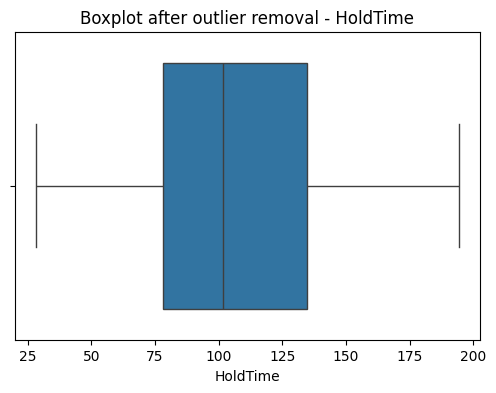

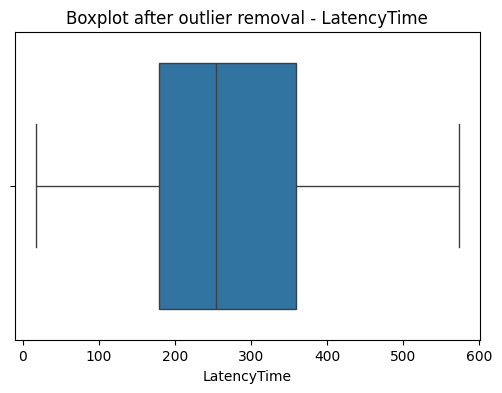

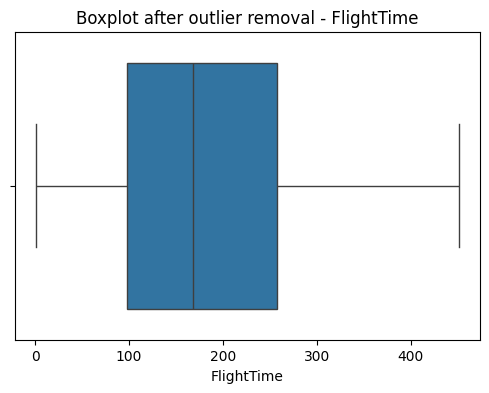

In [359]:
#Visulizing with box plots
import matplotlib.pyplot as plt
import seaborn as sns

for col in ["HoldTime", "LatencyTime", "FlightTime"]:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df_clean[col])
    plt.title(f"Boxplot after outlier removal - {col}")
    plt.show()

In [360]:
num_columns

['Hand', 'HoldTime', 'Direction', 'LatencyTime', 'FlightTime']

In [361]:
#Scaling the numerical columns
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(df[num_columns])

data_scaled = scaler.fit_transform(df[num_columns])

print(scaler.mean_)

[0.46470861 0.09710599 1.37635133 0.10107371 0.09281089]


In [362]:
#Keeping the preprocessed file another csv to facilate modeling

df.to_csv("modeling.csv", index=False)

In [363]:
#Visualizations 

import numpy as np


In [364]:
df

,Hand,HoldTime,Direction,LatencyTime,FlightTime,Parkinsons,Gender_Male
0,0,-0.276896,2,-0.695604,-0.683323,False,True
1,0,0.550265,2,1.369505,1.195503,True,False
3,1,1.239859,1,0.760712,0.975640,True,False
4,0,-0.035273,2,0.043406,-0.036852,True,True
6,1,0.068783,3,1.108514,1.292942,False,True
...,...,...,...,...,...,...,...
337314,1,0.206349,1,-0.347802,-0.853841,False,True
337316,0,-0.137566,2,0.848080,0.902561,False,False
337317,0,-0.895944,0,-0.086811,-0.048720,True,True
337321,0,0.550265,0,0.630495,0.414741,False,True


In [365]:
#Making sure everything is consistent one more time 

for col in df.columns:

    print(col)

    print()

    print(df[col].unique())


Hand

[0 1]
HoldTime

[-0.27689594  0.55026455  1.23985891 -0.03527337  0.06878307  0.68783069
 -0.96472663 -0.34567901  0.13756614 -0.12169312 -0.55202822 -0.48324515
 -0.68959436  1.44620811 -0.31040564  0.30864198  0.48148148  0.71428571
  0.27513228  0.34391534  0.         -0.06878307 -0.41446208  0.41269841
  0.96472663 -0.37918871  0.89417989  0.23985891 -0.82716049  1.34215168
  0.82539683  1.41622575  0.79188713 -0.89594356 -0.13756614  1.0670194
  1.51499118  1.10229277 -0.20811287  1.58377425 -0.10405644 -0.17283951
 -1.23985891  0.75661376 -1.0335097   0.20634921  1.0335097   1.17107584
  1.37742504  0.88712522  1.04938272  1.27336861  0.61904762 -0.62081129
  1.18694885 -1.10229277 -1.15520282 -0.41798942 -0.68077601 -0.72486772
 -0.75837743 -0.38095238  1.39506173  0.67724868  1.30864198  0.7319224
  0.49911817 -0.67195767  0.10229277 -0.6984127  -0.24162257  0.32627866
  0.86067019 -1.17107584 -1.15696649  1.13580247  0.67901235  0.5361552
  0.58906526  0.85361552 -0.5925

In [366]:
park_scaled = df["Parkinsons"]

In [367]:
park_scaled.isna().sum()

0

In [368]:
#Visualizations
import seaborn as sns
import matplotlib.pyplot as plt

Pairplot Visualizations

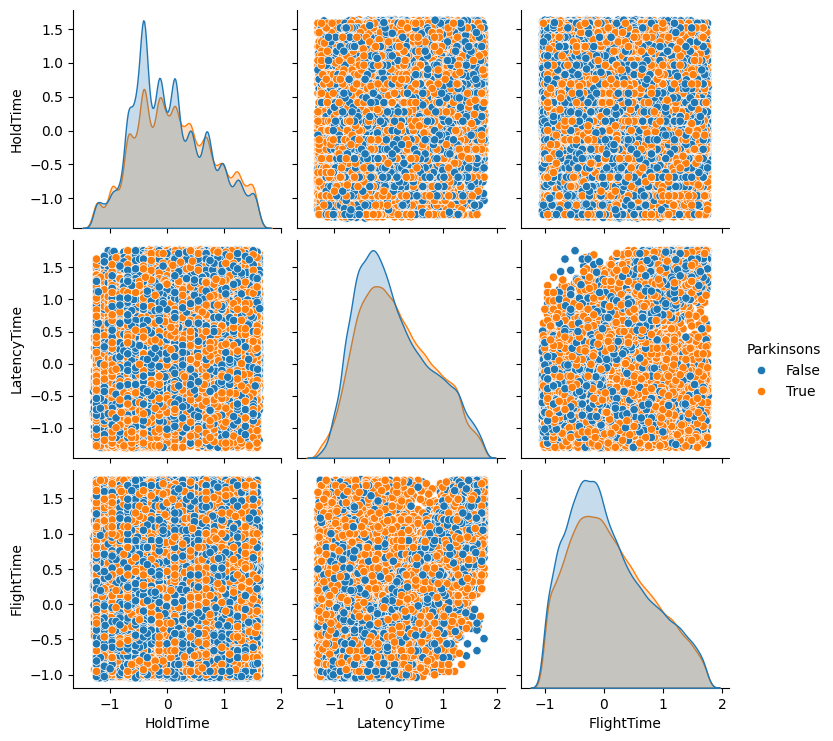

In [369]:
plt_columns = ["HoldTime", "LatencyTime", "FlightTime", "Parkinsons"]
sns.pairplot(df[plt_columns], hue="Parkinsons", diag_kind="kde")
plt.show()

Heatmap Correlations

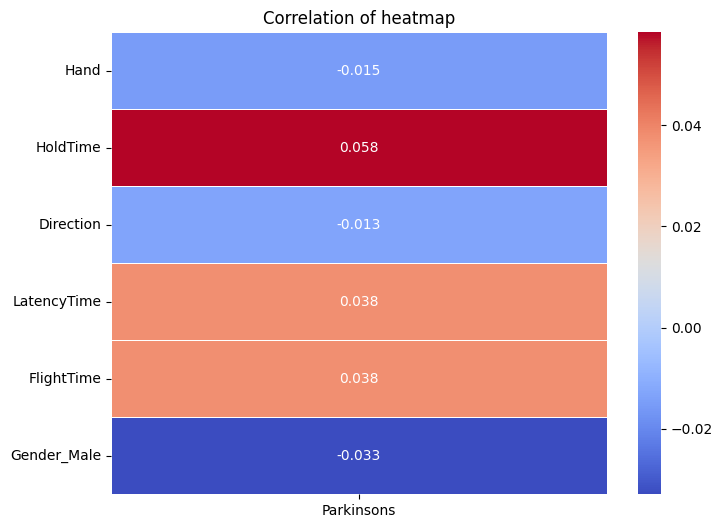

In [370]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr()[["Parkinsons"]].drop(index="Parkinsons"), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation of heatmap")
plt.show()


Histograms plotting for each feature

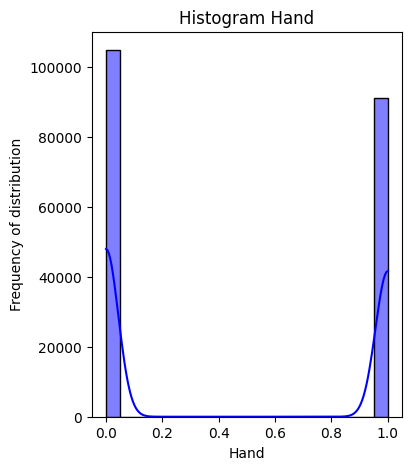

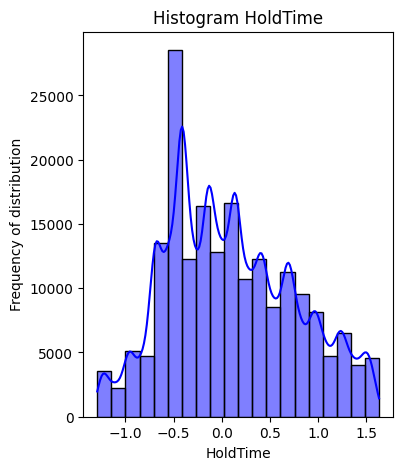

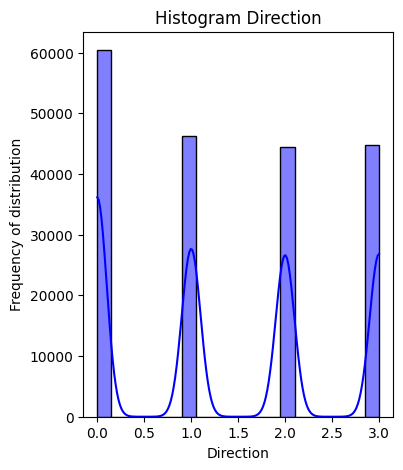

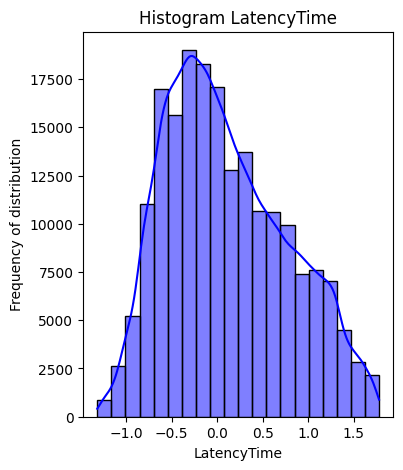

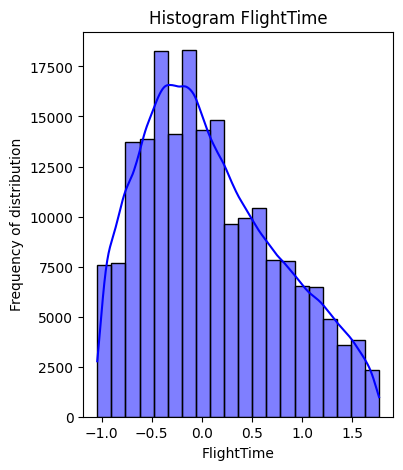

In [371]:
#Looping over num_columns for histogram plot
for col in num_columns:
    
    plt.figure(figsize=(4,5))
    sns.histplot(df[col], bins=20, kde=True, color="blue")
    plt.title("Histogram" + " " + col)
    plt.xlabel(col)
    plt.ylabel("Frequency of distribution")
    plt.show()

Visualizations after preprocessing 

In [372]:
len(num_columns)
print(num_columns)

['Hand', 'HoldTime', 'Direction', 'LatencyTime', 'FlightTime']


In [373]:
#Creating a dataframe with the scaled data and visualizing it again
df_scaled = pd.DataFrame(data=data_scaled, columns=num_columns)

df_scaled

,Hand,HoldTime,Direction,LatencyTime,FlightTime
0,-0.931741,-0.560322,0.545138,-1.195864,-1.158417
1,-0.931741,0.678913,0.545138,1.903997,1.645821
2,1.073260,1.712049,-0.328972,0.990160,1.317666
3,-0.931741,-0.198328,0.545138,-0.086563,-0.193528
4,1.073260,-0.042433,1.419248,1.512233,1.791254
...,...,...,...,...,...
196006,1.073260,0.163666,-0.328972,-0.673791,-1.412924
196007,-0.931741,-0.351581,0.545138,1.121305,1.208591
196008,-0.931741,-1.487767,-1.203083,-0.282028,-0.211241
196009,-0.931741,0.678913,-1.203083,0.794696,0.480496


Histogram visualizations

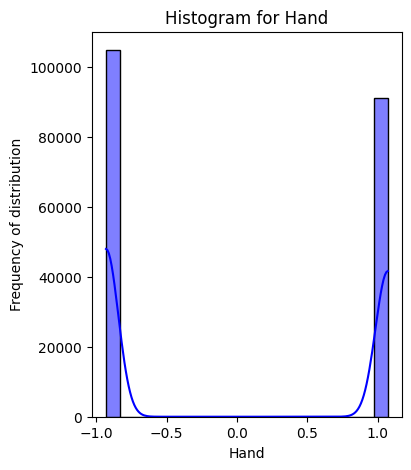

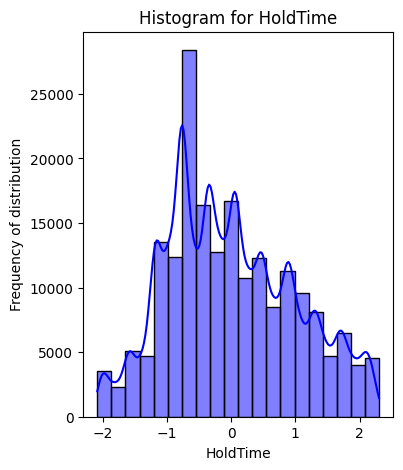

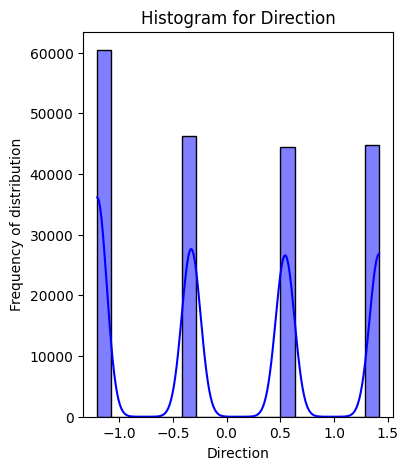

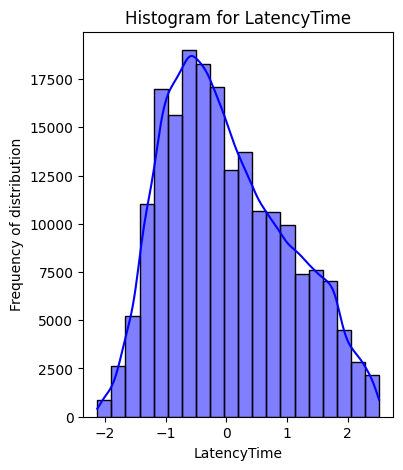

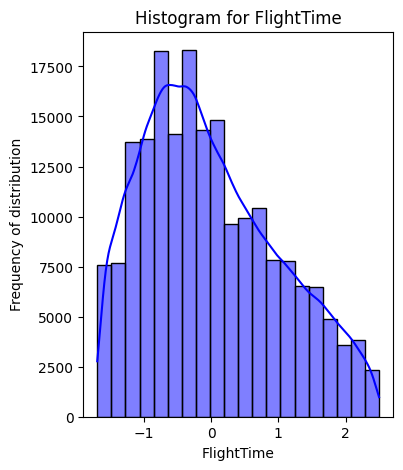

In [374]:
for col in num_columns:
    
    plt.figure(figsize=(4,5))
    sns.histplot(df_scaled[col], bins=20, kde=True, color="blue")
    plt.title("Histogram for" + " " + col)
    plt.xlabel(col)
    plt.ylabel("Frequency of distribution")
    plt.show()

Pairplot visualizations

Heatmap Visualizations

In [375]:
df_scaled["Parkinsons"] = park_scaled.reset_index(drop=True)

In [376]:
df_scaled["Parkinsons"].isna().sum()

0

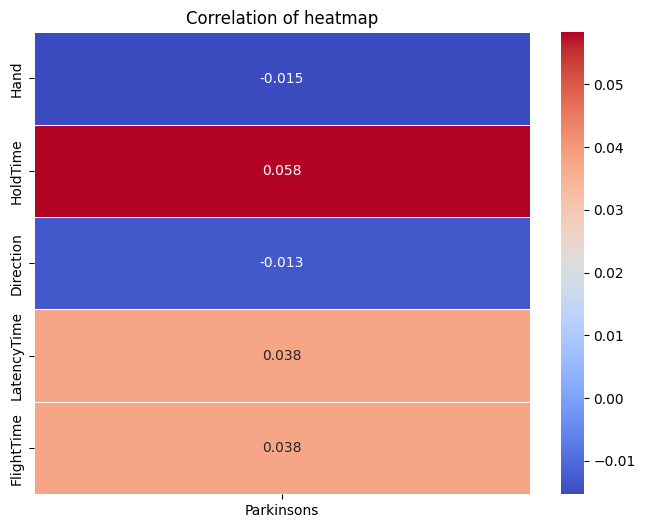

In [377]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_scaled.corr()[["Parkinsons"]].drop(index="Parkinsons"), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation of heatmap")
plt.show()


In [378]:
#Exporting this in the file directory for storage for a neural network

df_scaled.to_csv("nn.csv", index=False)